In [27]:
import pandas as pd
import xgboost as xgb 
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

In [3]:
telemetry = pd.read_csv("data/telemetry.csv")
summary = pd.read_csv("data/summary.csv")

In [4]:
f1 = pd.merge(telemetry, summary, on="LAPINDEX")

The new data set which contains a snapshot + summary statistics in each row has about 400,000 rows and 55 columns, some are identifiers, others are target variables. We have about 50 features to work with. 

In [5]:
# Let us create the train and test data. 
train, test = train_test_split(f1, test_size=0.2, train_size=0.8, random_state=42)

In [6]:
train

,SESSIONUID,CURRENTLAPNUM,SPEED,THROTTLE,STEER,BRAKE,GEAR,ENGINERPM,DRS,BRAKETEMPRL,...,AVGBRAKE,AVGTHROTTLE,PEAKBRAKE,PEAKTHROTTLE,BRAKEX,BRAKEY,BRAKEPOINTPRESSURE,TURNX,TURNY,TURNANGLE
349675,21F8FE8F85418FE9E0631618000A3D64,1,183.0,0.484655,0.007849,0.0,4.0,11220.0,1.0,189.0,...,0.021380,0.274338,0.156254,0.732845,NaN,NaN,0.000000,374.700920,193.746708,0.201404
26390,22D7F9FCB2CEF433E0631518000A7226,4,237.0,1.000000,-0.075670,0.0,6.0,10929.0,0.0,604.0,...,0.081308,0.905550,1.000000,1.000000,307.131290,280.091309,0.276424,364.062424,220.965453,0.204112
357333,248CD828DF2062DEE0631418000AA10E,1,196.0,1.000000,-0.146139,0.0,5.0,10746.0,0.0,752.0,...,0.093236,0.886374,1.000000,1.000000,304.459030,283.084815,0.260265,355.365197,233.558152,0.210350
103755,2507FD165CF949F0E0631318000AC74D,2,322.0,1.000000,0.001196,0.0,8.0,11525.0,1.0,288.0,...,0.081953,0.846274,1.000000,1.000000,313.741781,275.419157,0.234068,353.793405,231.936723,0.217456
20577,25816EC44540E08FE0631318000A748A,1,279.0,1.000000,-0.000000,0.0,7.0,11301.0,1.0,519.0,...,0.101379,0.911626,1.000000,1.000000,308.160618,279.718466,0.230600,354.781707,232.956730,0.206658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,240617A47493B160E0631418000AB4A4,1,247.0,0.694011,0.003784,0.0,6.0,11246.0,1.0,417.0,...,0.075608,0.635706,0.932019,1.000000,317.417313,270.583190,0.237941,357.691671,230.205392,0.210352
365838,3068D5C9518916B3E0631218000A2F89,2,184.0,0.307347,0.000379,0.0,4.0,11182.0,1.0,146.0,...,0.014352,0.337874,0.424894,0.485515,345.072725,232.996551,0.224762,376.375232,194.970415,0.201897
131932,240617AB6201B172E0631418000AE706,11,189.0,1.000000,-0.193942,0.0,5.0,10402.0,0.0,742.0,...,0.128974,0.832021,1.000000,1.000000,302.942912,284.395921,0.211781,350.767983,237.440007,0.208462
146867,24DC38837A340381E0631318000A8139,4,149.0,1.000000,-0.006803,0.0,4.0,10489.0,0.0,792.0,...,0.107134,0.863782,1.000000,1.000000,308.965581,276.226752,0.360113,368.831974,200.451171,0.200091


In [7]:
test

,SESSIONUID,CURRENTLAPNUM,SPEED,THROTTLE,STEER,BRAKE,GEAR,ENGINERPM,DRS,BRAKETEMPRL,...,AVGBRAKE,AVGTHROTTLE,PEAKBRAKE,PEAKTHROTTLE,BRAKEX,BRAKEY,BRAKEPOINTPRESSURE,TURNX,TURNY,TURNANGLE
249239,212FF31CD7D48FBDE0631218000A73E8,1,286.0,0.834266,0.014429,0.000000,7.0,11522.0,1.0,310.0,...,0.050083,0.738593,0.557610,1.0,317.618467,272.233811,0.206420,377.088409,125.894651,-0.203612
242777,285526CE33E3A101E0631818000A8BA5,2,189.0,0.807290,-0.113302,0.000000,5.0,10247.0,0.0,430.0,...,0.058070,0.525292,0.631381,1.0,220.463238,361.559683,0.215861,NaN,NaN,0.000000
371522,2413BB6D8895C2B7E0631418000AA98A,1,173.0,1.000000,0.846969,0.000000,5.0,9389.0,1.0,533.0,...,0.074122,0.871724,0.900000,1.0,301.923642,279.004078,0.289117,335.045797,245.641719,0.228554
2299,30A8F0548E1EA719E0631218000ADC99,3,258.0,0.136568,0.004737,0.743789,7.0,10058.0,0.0,638.0,...,0.074865,0.897629,0.765649,1.0,292.927166,294.183250,0.216061,346.522870,243.121353,0.200576
190198,2580948CF584514DE0631318000AD338,2,285.0,1.000000,-0.031665,0.000000,7.0,11559.0,1.0,426.0,...,0.079799,0.804196,1.000000,1.0,295.139866,293.599932,0.285409,358.283861,229.378219,0.202942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381769,2509A909814F1F2CE0631318000A4D58,2,284.0,1.000000,-0.046391,0.000000,7.0,11467.0,1.0,384.0,...,0.062515,0.850334,1.000000,1.0,292.305230,294.979211,0.204322,357.267536,232.643620,0.227085
28171,31D5ED911FDDA555E0631818000A2299,2,167.0,0.122362,0.328311,0.100549,4.0,10035.0,0.0,762.0,...,0.080352,0.865989,1.000000,1.0,305.580217,282.807641,0.234137,368.046057,215.022204,0.204169
329396,25810C7FE491A5F7E0631318000A35C1,2,113.0,0.000000,-0.270401,0.000000,3.0,8112.0,0.0,647.0,...,0.170790,0.629731,1.000000,1.0,217.098890,366.687339,0.232914,354.018170,235.043272,0.203025
361922,31D5ED8FFA477286E0631818000AC168,1,238.0,1.000000,-0.004316,0.105921,6.0,10860.0,0.0,693.0,...,0.348202,0.983755,0.565724,1.0,196.991735,383.342202,0.200649,353.657876,231.797178,0.211972


We have about 330,000 training rows and about 82,557 rows. Let us begin by dropping the indentifiers like `SESSIONUID` and `CURRENTLAPNUM`. Variables such as `TURN` rely on the X,Y position of the car, it may well be redundant as it is not informative everywhere and is essentially a categroical variable disguised as a numeric one. 

In [8]:
def preprocess(df: pd.DataFrame):
    # X matrix processing
    X = df.drop(columns=["SESSIONUID", "CURRENTLAPNUM", "TURN", "EXITSPEED", "LAPINDEX"])
    
    y = df["EXITSPEED"]

    return X, y

In [9]:
train_X, train_y = preprocess(train)

In [10]:
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
model.fit(train_X, train_y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [11]:
test_X, test_y = preprocess(train)

In [ ]:
pred_y = model.predict(test_X)
rmse = root_mean_squared_error(test_y, pred_y)
mse = mean_squared_error(test_y, pred_y)
r2 = r2_score(test_y, pred_y)

In [13]:
rmse

0.07951630051637898

The RMSE is too good, something has gone awry. My hypothesis is that the data provided in the train and test data, are not independent. As a result, were giving the training data some point x while the train data may have access to point x+1 from the same lap. Its almost as if we're producing the training RMSE. To fix this, we must run a GroupShuffleSplit

In [14]:
groups = f1["LAPINDEX"]
gss = GroupShuffleSplit(n_splits=2, train_size=0.8, random_state=42)
train_i, test_i = next(gss.split(f1, groups=groups))

In [15]:
train = f1.iloc[train_i].reset_index(drop=True)
test  = f1.iloc[test_i].reset_index(drop=True)

In [16]:
train_X, train_y = preprocess(train)

Now that we have a split that can guarantee independence across the train and test splits, let us see how well the "naive" model is able to perform.

In [17]:
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
model.fit(train_X, train_y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [18]:
test_X, test_y = preprocess(test)

In [28]:
pred_y = model.predict(test_X)
rmse = root_mean_squared_error(test_y, pred_y)
mse = mean_squared_error(test_y, pred_y)
r2 = r2_score(test_y, pred_y)

In [30]:
r2, rmse

(0.5116397235311583, 30.84788286652174)

RMSE is around 25 with this simple change. Much more believable, even though the goal is to provide actionable insights for our let us look for models that minimise RMSE to the greatest extend.

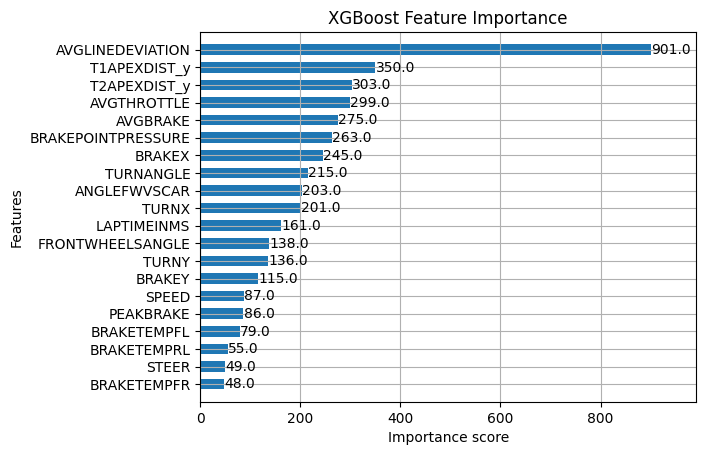

In [21]:
xgb.plot_importance(model, max_num_features=20, height=0.6)
plt.title("XGBoost Feature Importance")
plt.show()

We see that the most important factor is the deviation from the Racing line displayed on track. Secondly, getting closer to the apexes of either corners a key point also.

In [24]:
summary.sort_values(by="EXITSPEED", ascending=False)

,LAPINDEX,EXITSPEED,AVGLINEDEVIATION,T1APEXDIST,T2APEXDIST,AVGBRAKE,AVGTHROTTLE,PEAKBRAKE,PEAKTHROTTLE,BRAKEX,BRAKEY,BRAKEPOINTPRESSURE,TURNX,TURNY,TURNANGLE
83,76,309.0,2.263017,1.362859,0.459835,0.088443,0.884079,1.000000,1.000000,308.267754,278.386625,0.288549,372.686846,197.391291,0.201581
42,356,309.0,1.225408,2.710909,3.934172,0.093983,0.918505,1.000000,1.000000,312.947385,276.036639,0.341804,362.809855,223.980874,0.202340
33,77,309.0,2.175747,1.439260,0.332786,0.088085,0.903626,1.000000,1.000000,312.123589,275.180299,0.276070,370.769938,202.057054,0.200350
17,295,309.0,0.853310,0.580327,0.818239,0.087972,0.894416,1.000000,1.000000,310.735779,278.066874,0.253521,372.781564,201.403367,0.201775
15,410,309.0,1.223221,4.644724,1.737971,0.089285,0.916107,1.000000,1.000000,308.757685,278.895794,0.259063,356.981943,226.602529,0.206996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,362,123.0,5.980948,1.455715,11.753797,0.161085,0.525427,1.000000,1.000000,336.474262,241.364911,0.329407,351.309577,226.502290,0.208533
331,307,117.0,1.018931,2.094522,0.095316,0.170790,0.629731,1.000000,1.000000,217.098890,366.687339,0.232914,354.018170,235.043272,0.203025
405,328,112.0,4.596497,16.699222,2.527590,0.194653,0.655072,1.000000,1.000000,263.327473,319.609603,0.208516,360.248998,170.894640,-0.227711
400,326,107.0,4.357475,4.136619,9.009738,0.014358,0.129348,0.746238,0.472543,326.633214,254.204691,0.242518,NaN,NaN,0.000000
